In [1]:
from velox_tools import campaign
import xarray as xr
import numpy as np
from tqdm import tqdm

In [2]:
import fsspec

In [3]:
import os
os.environ["IPFS_GATEWAY"] = "https://ipfs.orcestra-campaign.org"

import xarray as xr

cid = "bafybeiesyutuduzqwvu4ydn7ktihjljicywxeth6wtgd5zi4ynxzqngx4m"

ds = xr.open_dataset(
    f"ipfs://{cid}",
    engine="zarr",
)

ds

<xarray.Dataset> Size: 85MB
Dimensions:            (sonde: 1115, altitude: 1460)
Coordinates:
  * altitude           (altitude) float64 12kB 0.0 10.0 ... 1.458e+04 1.459e+04
    launch_altitude    (sonde) float32 4kB ...
    launch_lat         (sonde) float32 4kB ...
    launch_lon         (sonde) float32 4kB ...
    launch_time        (sonde) datetime64[ns] 9kB ...
Dimensions without coordinates: sonde
Data variables: (12/23)
    flight_id          (sonde) <U14 62kB ...
    interpolated_time  (sonde, altitude) datetime64[ns] 13MB ...
    iwv                (sonde) float32 4kB ...
    lat                (sonde, altitude) float32 7MB ...
    lon                (sonde, altitude) float32 7MB ...
    p                  (sonde, altitude) float32 7MB ...
    ...                 ...
    u_qc               (sonde) int8 1kB ...
    v                  (sonde, altitude) float32 7MB ...
    v_qc               (sonde) int8 1kB ...
    vaisala_serial_id  (sonde) <U9 40kB ...
    wdir               (sonde, altitude) float32 7MB ...
    wspd               (sonde, altitude) float32 7MB ...
Attributes:
    creator_email:  helene.gloeckner@mpimet.mpg.de, theresa.mieslinger@mpimet...
    creator_name:   Helene Gloeckner, Theresa Mieslinger, Nina Robbins
    featureType:    trajectoryProfile
    history:        Level 1 ASPEN processing with Aspen V4.0.4 \nLevel 2 qual...
    keywords:       ORCESTRA, BEACH, Sounding, Dropsondes, Tropics, Atmospher...
    license:        CC-BY-4.0
    platform:       HALO
    project:        ORCESTRA, PERCUSION, MAESTRO
    references:     https://github.com/atmdrops/pydropsonde
    source:         dropsondes
    summary:        This dataset is the Level 3 BEACH dataset. It contains qu...
    title:          BEACH dropsonde dataset (Level 3)

In [4]:
ds.launch_time.values

array(['2024-08-09T14:27:28.000000000', '2024-08-09T14:45:33.000000000',
       '2024-08-09T15:05:24.000000000', ...,
       '2024-09-28T19:04:52.000000000', '2024-09-28T19:09:51.000000000',
       '2024-09-28T19:14:52.000000000'],
      shape=(1115,), dtype='datetime64[ns]')

In [5]:
WINDOW_SECONDS = 60
launch_time_slices = [
    slice(t - np.timedelta64(WINDOW_SECONDS, 's'),
          t + np.timedelta64(WINDOW_SECONDS, 's'))
    for t in ds.launch_time.values
]


Load ±60 seconds around each launch with 20 processes. The helper reads only the pushbroom rows directly from netCDF, reuses open files within each batch, and uses the existing georeferencing and ground-time correction. All five channels are retained.

Progress advances as batches finish. Successful datasets stay in launch order; `ds_velox_dropsonde_indices` maps them back to the original launches. `velox_errors` records failures, and `velox_timings` shows where each successful window spent its time.


In [6]:
from collections import defaultdict
from concurrent.futures import as_completed
from contextlib import ExitStack
from time import perf_counter

import pandas as pd
from joblib.externals.loky import ProcessPoolExecutor
from tqdm.auto import tqdm

N_WORKERS = 20
SLICES_PER_TASK = 4  # Reuse open flight files, with enough tasks to balance workers.
CHANNELS = tuple(campaign.CHANNELS)
SLICING_POSITION = 250


def pushbroom_from_open_files(files, nav, time_slice, channels, slicing_position):
    """Read just the pushbroom rows; retain the campaign geometry/time correction."""
    from velox_tools import campaign, processing

    started = perf_counter()
    time = files[0].time.sel(time=time_slice)
    time = time.sel(time=slice(nav.time.values[0], nav.time.values[-1]))
    if time.size == 0:
        raise ValueError("No VELOX frames within this window and navigation coverage")

    # Keep both interpolation neighbours, instead of interpolating a whole flight.
    nav_time = nav.time.values
    lo = max(0, int(nav_time.searchsorted(time.values[0])) - 1)
    hi = min(len(nav_time), int(nav_time.searchsorted(time.values[-1], side="right")) + 1)
    nav = nav.isel(time=slice(lo, hi))
    frame_nav = nav.interp(time=time)
    pps = processing.compute_pixel_per_second(frame_nav)
    stop = min(slicing_position + int(pps.max()), files[0].sizes["y"])
    strip = slice(slicing_position, stop)
    bands = []
    for raw in files:
        # Slice the netCDF backend BEFORE loading or aligning channels.
        band = raw["BT_2D"].sel(time=time_slice).isel(y=strip)
        band = band.transpose("time", "x", "y").load()
        band = band.reindex(time=time, method="nearest", tolerance=np.timedelta64(500, "ms"))
        bands.append(band)
    compact = xr.concat(bands, dim="band").to_dataset(name="BT_2D")
    compact = compact.assign_coords(
        band=list(channels), x=np.arange(compact.sizes["x"]),
        y=np.arange(compact.sizes["y"]),
    )
    compact.attrs = dict(zip(("campaign", "research_flight"), campaign.flight(time_slice)))
    read_seconds = perf_counter() - started

    started = perf_counter()
    geo = campaign._georef_series(
        compact, nav, channels[0], rows=np.arange(slicing_position, stop)
    ).assign_coords(y=compact.y)
    compact = compact.assign(lats=geo.lats, lons=geo.lons)
    georef_seconds = perf_counter() - started

    started = perf_counter()
    output = processing.pushbroom(
        compact, slicing_position=0, nav_data=nav, time_correction=False
    )
    # The compact array starts at row zero, but ground time uses the original row.
    ground_time = processing._build_ground_time_axis(
        frame_times=time.values, pitch=frame_nav["pitch"].values,
        roll=frame_nav["roll"].values, alt=frame_nav["alt"].values,
        gs=frame_nav["gs"].values, pixel_per_second=pps,
        slicing_position=slicing_position,
    )
    output = output.assign_coords(time=ground_time).sortby("time")
    return output, (read_seconds, georef_seconds, perf_counter() - started)


def load_batch(items, channels, slicing_position):
    from velox_tools import campaign

    # Separate processes own their netCDF handles; close them after each batch.
    with ExitStack() as stack:
        try:
            flight_name, rf = campaign.flight(items[0][1])
            nav = campaign.load_nav(items[0][1])
            files = [stack.enter_context(xr.open_dataset(
                campaign._path(flight_name, rf, "velox", channel=channel),
                chunks=None, cache=False,
            )) for channel in channels]
        except Exception as exc:
            return [(i, None, str(exc), None) for i, _ in items]
        results = []
        for i, time_slice in items:
            try:
                output, timing = pushbroom_from_open_files(
                    files, nav, time_slice, channels, slicing_position
                )
                results.append((i, output, None, timing))
            except Exception as exc:
                results.append((i, None, str(exc), None))
        return results


In [7]:
# Group nearby slices from the same flight to reuse file handles and OS read cache.
by_flight = defaultdict(list)
results, errors, timings = {}, {}, {}
for i, time_slice in enumerate(launch_time_slices):
    try:
        by_flight[campaign.flight(time_slice)].append((i, time_slice))
    except Exception as exc:
        errors[i] = str(exc)
batches = []
for items in by_flight.values():
    items.sort(key=lambda item: item[1].start)
    batches.extend(items[j:j + SLICES_PER_TASK] for j in range(0, len(items), SLICES_PER_TASK))

started = perf_counter()
# Loky serializes notebook functions; as_completed works with joblib 1.3 too.
thread_env = {name: "1" for name in (
    "OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
    "BLIS_NUM_THREADS", "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS",
)}
with tqdm(total=len(launch_time_slices), initial=len(errors), desc=f"VELOX ±{WINDOW_SECONDS} s") as progress:
    for i, error in errors.items():
        tqdm.write(f"Failed to load velox for launch time slice {launch_time_slices[i]}: {error}")
    if batches:
        with ProcessPoolExecutor(max_workers=N_WORKERS, env=thread_env) as pool:
            pending = {pool.submit(load_batch, batch, CHANNELS, SLICING_POSITION): batch
                       for batch in batches}
            for future in as_completed(pending):
                batch = pending.pop(future)
                # Unexpected worker/process failures should surface, not silently lose data.
                for i, output, error, timing in future.result():
                    if error is None:
                        results[i], timings[i] = output, timing
                    else:
                        errors[i] = error
                        tqdm.write(f"Failed to load velox for launch time slice {launch_time_slices[i]}: {error}")
                progress.update(len(batch))
                progress.set_postfix(loaded=len(results), failed=len(errors))

# Keep the original list of successful datasets, plus their original launch indices.
ds_velox_dropsonde_indices = sorted(results)
ds_velox_dropsonde = [results[i] for i in ds_velox_dropsonde_indices]
velox_errors = errors
velox_timings = pd.DataFrame.from_dict(
    timings, orient="index", columns=["read_s", "georef_s", "assemble_s"]
).sort_index().rename_axis("launch_index")
print(f"Loaded {len(results)}/{len(launch_time_slices)} windows in {perf_counter() - started:.1f} s")
if not velox_timings.empty:
    print("Mean seconds per successful window (across workers):")
    print(velox_timings.mean().round(2))


VELOX ±60 s:   0%|          | 3/1115 [00:00<?, ?it/s]

Failed to load velox for launch time slice slice(np.datetime64('2024-08-09T14:26:28.000000000'), np.datetime64('2024-08-09T14:28:28.000000000'), None): no research flight with final VELOX data on 2024-08-09
Failed to load velox for launch time slice slice(np.datetime64('2024-08-09T14:44:33.000000000'), np.datetime64('2024-08-09T14:46:33.000000000'), None): no research flight with final VELOX data on 2024-08-09
Failed to load velox for launch time slice slice(np.datetime64('2024-08-09T15:04:24.000000000'), np.datetime64('2024-08-09T15:06:24.000000000'), None): no research flight with final VELOX data on 2024-08-09
Failed to load velox for launch time slice slice(np.datetime64('2024-08-16T19:13:47.000000000'), np.datetime64('2024-08-16T19:15:47.000000000'), None): No VELOX frames within this window and navigation coverage
Failed to load velox for launch time slice slice(np.datetime64('2024-08-16T19:17:42.000000000'), np.datetime64('2024-08-16T19:19:42.000000000'), None): No VELOX frames 

/projekt_agmwend/home_rad/Joshua/micromamba/envs/mamba_josh/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Failed to load velox for launch time slice slice(np.datetime64('2024-09-21T11:49:38.000000000'), np.datetime64('2024-09-21T11:51:38.000000000'), None): No VELOX frames within this window and navigation coverage


/projekt_agmwend/home_rad/Joshua/micromamba/envs/mamba_josh/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Loaded 1053/1115 windows in 608.3 s
Mean seconds per successful window (across workers):
read_s        8.85
georef_s      1.74
assemble_s    0.08
dtype: float64


In [8]:
ds_test = ds_velox_dropsonde[100]


In [9]:
ds_test

<xarray.Dataset> Size: 48MB
Dimensions:  (band: 5, y: 635, time: 2106)
Coordinates:
  * y        (y) int64 5kB 0 1 2 3 4 5 6 7 8 ... 627 628 629 630 631 632 633 634
  * band     (band) int64 40B 1 2 3 5 6
  * time     (time) datetime64[ns] 17kB 2024-08-16T14:04:30.085752873 ... 202...
Data variables:
    BT_2D    (band, y, time) float32 27MB 9.874 10.05 9.954 ... 7.84 8.26 7.22
    lats     (y, time) float64 11MB 3.871 3.871 3.871 ... 3.602 3.602 3.602
    lons     (y, time) float64 11MB -33.96 -33.96 -33.96 ... -33.99 -33.99
Attributes:
    campaign:         PERCUSION
    research_flight:  RF03

In [10]:
ds_radar = xr.open_dataset("ipfs://bafybeigmd3dovwm45ylfqxnn2jphsrdjl2jt3dfytv7grkyhleaq42jthe", engine="zarr")

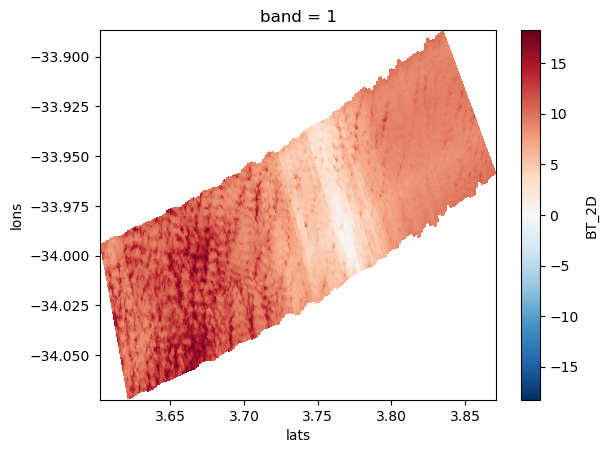

In [11]:
ds_test = ds_velox_dropsonde[100].isel(band=0).assign_coords(
    lats=ds_velox_dropsonde[100].isel(band=0)['lats'],
    lons=ds_velox_dropsonde[100].isel(band=0)['lons']
)
ds_test['BT_2D'].plot.pcolormesh(x='lats', y='lons')

In [12]:
ds_dropsonde = ds.load()
ds_dropsonde

<xarray.Dataset> Size: 85MB
Dimensions:            (sonde: 1115, altitude: 1460)
Coordinates:
  * altitude           (altitude) float64 12kB 0.0 10.0 ... 1.458e+04 1.459e+04
    launch_altitude    (sonde) float32 4kB 1.4e+04 1.398e+04 ... 1.441e+04
    launch_lat         (sonde) float32 4kB 22.04 20.02 17.83 ... 10.23 10.34
    launch_lon         (sonde) float32 4kB -19.62 -20.92 -22.4 ... -55.82 -56.33
    launch_time        (sonde) datetime64[ns] 9kB 2024-08-09T14:27:28 ... 202...
Dimensions without coordinates: sonde
Data variables: (12/23)
    flight_id          (sonde) <U14 62kB 'HALO-20240809b' ... 'HALO-20240928a'
    interpolated_time  (sonde, altitude) datetime64[ns] 13MB 2024-08-09T14:43...
    iwv                (sonde) float32 4kB 27.89 nan 39.15 ... 47.62 46.79 46.26
    lat                (sonde, altitude) float32 7MB 22.01 22.01 ... nan nan
    lon                (sonde, altitude) float32 7MB -19.69 -19.69 ... nan nan
    p                  (sonde, altitude) float32 7MB 1.012e+05 1.011e+05 ... nan
    ...                 ...
    u_qc               (sonde) int8 1kB 0 1 0 0 0 0 0 0 0 ... 0 0 0 0 0 1 0 0 0
    v                  (sonde, altitude) float32 7MB -8.166 -8.224 ... nan nan
    v_qc               (sonde) int8 1kB 0 1 0 0 0 0 0 0 0 ... 0 0 0 0 0 1 0 0 0
    vaisala_serial_id  (sonde) <U9 40kB '231221036' '231330751' ... '232320070'
    wdir               (sonde, altitude) float32 7MB 26.68 28.14 ... nan nan
    wspd               (sonde, altitude) float32 7MB 9.139 9.326 ... nan nan
Attributes:
    creator_email:  helene.gloeckner@mpimet.mpg.de, theresa.mieslinger@mpimet...
    creator_name:   Helene Gloeckner, Theresa Mieslinger, Nina Robbins
    featureType:    trajectoryProfile
    history:        Level 1 ASPEN processing with Aspen V4.0.4 \nLevel 2 qual...
    keywords:       ORCESTRA, BEACH, Sounding, Dropsondes, Tropics, Atmospher...
    license:        CC-BY-4.0
    platform:       HALO
    project:        ORCESTRA, PERCUSION, MAESTRO
    references:     https://github.com/atmdrops/pydropsonde
    source:         dropsondes
    summary:        This dataset is the Level 3 BEACH dataset. It contains qu...
    title:          BEACH dropsonde dataset (Level 3)

In [13]:
ds_velox_dropsonde_indices[100]

103

In [14]:
len(ds_velox_dropsonde)

1053

In [15]:
# Rough bounding-box check only; the distance sampling below tests the actual swath.

ds

for velox_i, sonde_i in enumerate(ds_velox_dropsonde_indices):
    lat = ds_dropsonde['lat'].isel(sonde=sonde_i)
    lon = ds_dropsonde['lon'].isel(sonde=sonde_i)

    ds_velox = ds_velox_dropsonde[velox_i]

    velox_lats = ds_velox['lats']
    velox_lons = ds_velox['lons']
    
    lat_in_range = (lat >= velox_lats.min()) & (lat <= velox_lats.max())
    lon_in_range = (lon >= velox_lons.min()) & (lon <= velox_lons.max())

    all_lat_in_range = lat_in_range.all()
    all_lon_in_range = lon_in_range.all()

    if all_lat_in_range and all_lon_in_range:
        print(f'Sonde {sonde_i}: all lat/lon in range: {all_lat_in_range and all_lon_in_range}')

/projekt_agmwend/home_rad/Joshua/micromamba/envs/mamba_josh/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


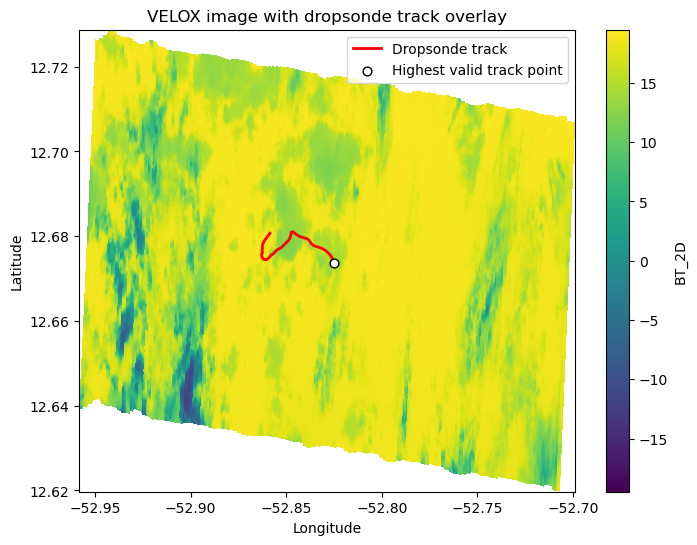

In [16]:
test_i = 680
ds_test = ds_velox_dropsonde[test_i]
ds_test = ds_test.assign_coords(
    lons=ds_test["lons"],
    lats=ds_test["lats"]
)
ds_dropsonde_test = ds_dropsonde.isel(sonde=ds_velox_dropsonde_indices[test_i])

import matplotlib.pyplot as plt

velox_da = ds_test["BT_2D"]
if "band" in velox_da.dims:
    velox_da = velox_da.isel(band=0)

track_lon = ds_dropsonde_test["lon"].values
track_lat = ds_dropsonde_test["lat"].values
valid = np.isfinite(track_lon) & np.isfinite(track_lat)

fig, ax = plt.subplots(figsize=(8, 6))
velox_da.plot.pcolormesh(
    x="lons",
    y="lats",
    ax=ax,
    cmap="viridis",
    add_colorbar=True,
)
ax.plot(track_lon[valid], track_lat[valid], color="red", lw=2, label="Dropsonde track")
ax.scatter(track_lon[valid][-1], track_lat[valid][-1], color="white", edgecolor="black", s=40, zorder=3, label="Highest valid track point")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
ax.set_title("VELOX image with dropsonde track overlay")
plt.show()

### Thermal-image surroundings of each dropsonde

Query **every image pixel against the small track tree once**, then reuse its distance for
500, 1,000, 2,500 and 5,000 m (extend `RADII_M` below). Each cumulative neighbourhood
contains every finite BT pixel within that radius of any valid sampled track position,
counted once per image. Neighbourhoods overlap; different radii are not independent samples.
`track_bt_stats` keeps only per-sonde summaries, avoiding a campaign-sized pixel table.
The example map retains pixel-level distances for one window.

Distances are horizontal great-circle distances on a spherical Earth to **sampled positions**,
not altitude-dependent 3-D distances or exact distances to connecting line segments.
Missing track portions are not bridged. `max_track_step_m` reports the largest separation
of adjacent valid positions; inspect it if comparable to the smallest radius.
`TRACK_ALTITUDE_M` can restrict the track, e.g. `(0, 4000)` for the lower troposphere.

Interpretation: the available swath may cover only part of a neighbourhood, especially at
5 km; counts are observed pixels, not an area-coverage or cloud-fraction estimate. Statistics
are pixel-weighted and include clear sky and clouds. The existing sea-level georeferencing
has no cloud-height/parallax correction. Images near launch and the later descending track
are not simultaneous or wind-advected into alignment. These are spatial context statistics,
not a measurement of the same evolving cloud parcel. BT stays in the campaign's °C units;
it is not automatically cloud-top temperature or height.

In [17]:
from scipy.spatial import cKDTree

RADII_M = np.array([500, 1000, 2500, 5000], dtype=float)
BAND_INDEX = 0  # Existing broadband channel; index 2 is the 10.74 µm window channel.
TRACK_ALTITUDE_M = (0, np.inf)
EXAMPLE_INDEX = min(680, len(ds_velox_dropsonde) - 1)
EARTH_RADIUS_M = 6_371_000.0
assert RADII_M.size and np.all(np.isfinite(RADII_M)) and np.all(RADII_M > 0)
assert np.all(np.diff(RADII_M) > 0), "Use increasing, unique radii"
assert len(ds_velox_dropsonde) == len(ds_velox_dropsonde_indices)


def earth_xyz(lat, lon):
    lat, lon = np.deg2rad(lat), np.deg2rad(lon)
    return EARTH_RADIUS_M * np.column_stack([
        np.cos(lat) * np.cos(lon), np.cos(lat) * np.sin(lon), np.sin(lat)
    ])


def track_distances(image, sonde):
    """Distance to sampled track positions; NaN for invalid geo, inf beyond max radius."""
    lat, lon = image.lats.transpose('y', 'time').values, image.lons.transpose('y', 'time').values
    tlat, tlon = sonde.lat.values, sonde.lon.values
    valid_track = (np.isfinite(tlat) & np.isfinite(tlon) & (np.abs(tlat) <= 90)
                   & (sonde.altitude.values >= TRACK_ALTITUDE_M[0])
                   & (sonde.altitude.values <= TRACK_ALTITUDE_M[1]))
    valid_pixel = np.isfinite(lat) & np.isfinite(lon) & (np.abs(lat) <= 90)
    distance = np.full(lat.shape, np.nan)
    if not valid_track.any():
        return distance, np.nan
    xyz = earth_xyz(tlat[valid_track], tlon[valid_track])
    # Only consecutive original profile samples: do not span missing sections.
    adjacent = np.diff(np.flatnonzero(valid_track)) == 1
    steps = np.linalg.norm(np.diff(xyz, axis=0), axis=1)[adjacent]
    max_step = 2 * EARTH_RADIUS_M * np.arcsin(np.clip(steps.max() / (2 * EARTH_RADIUS_M), 0, 1)) if steps.size else np.nan
    chord_limit = 2 * EARTH_RADIUS_M * np.sin(RADII_M[-1] / (2 * EARTH_RADIUS_M))
    chord, _ = cKDTree(xyz).query(
        earth_xyz(lat[valid_pixel], lon[valid_pixel]),
        distance_upper_bound=np.nextafter(chord_limit, np.inf), workers=1,
    )
    arc = np.full(chord.shape, np.inf)
    finite = np.isfinite(chord)
    arc[finite] = 2 * EARTH_RADIUS_M * np.arcsin(np.clip(chord[finite] / (2 * EARTH_RADIUS_M), 0, 1))
    distance[valid_pixel] = arc
    return distance, max_step


rows, example_distance_m = [], None
for velox_i, image in enumerate(tqdm(ds_velox_dropsonde, desc='Sampling track surroundings')):
    sonde_i = int(ds_velox_dropsonde_indices[velox_i])
    distance, max_step = track_distances(image, ds_dropsonde.isel(sonde=sonde_i))
    bt = image.BT_2D
    if 'band' in bt.dims:
        bt = bt.isel(band=BAND_INDEX)
    bt = bt.transpose('y', 'time').values
    for radius in RADII_M:
        inside = distance <= radius
        values = bt[inside & np.isfinite(bt)]
        p10, median, p90 = np.percentile(values, [10, 50, 90]) if values.size else [np.nan] * 3
        rows.append(dict(
            velox_list_index=velox_i, sonde_index=sonde_i, radius_m=radius,
            n_geo_pixels=int(inside.sum()), n_pixels=values.size, max_track_step_m=max_step,
            bt_mean=values.mean() if values.size else np.nan,
            bt_std=values.std() if values.size else np.nan,
            bt_p10=p10, bt_median=median, bt_p90=p90,
        ))
    if velox_i == EXAMPLE_INDEX:
        example_distance_m = distance

track_bt_stats = pd.DataFrame(rows, columns=[
    'velox_list_index', 'sonde_index', 'radius_m', 'n_geo_pixels', 'n_pixels',
    'max_track_step_m', 'bt_mean', 'bt_std', 'bt_p10', 'bt_median', 'bt_p90',
])
print(f'{len(track_bt_stats)} summaries; pixels counted once within each radius/window')
track_bt_stats.head()

Sampling track surroundings:   0%|          | 0/1053 [00:00<?, ?it/s]

4212 summaries; pixels counted once within each radius/window


,velox_list_index,sonde_index,radius_m,n_geo_pixels,n_pixels,max_track_step_m,bt_mean,bt_std,bt_p10,bt_median,bt_p90
0,0,3,500.0,32790,32790,32.909916,15.217463,0.920617,14.203352,15.219363,16.222672
1,0,3,1000.0,67268,67268,32.909916,14.314932,2.023032,11.918025,14.876802,15.985483
2,0,3,2500.0,194620,194620,32.909916,10.704625,7.386861,-4.053796,14.407108,16.035423
3,0,3,5000.0,471887,471887,32.909916,10.134533,7.563772,-4.129303,13.561458,16.409473
4,1,4,500.0,28889,28889,175.477921,19.172289,0.887669,17.897911,19.284552,20.223000


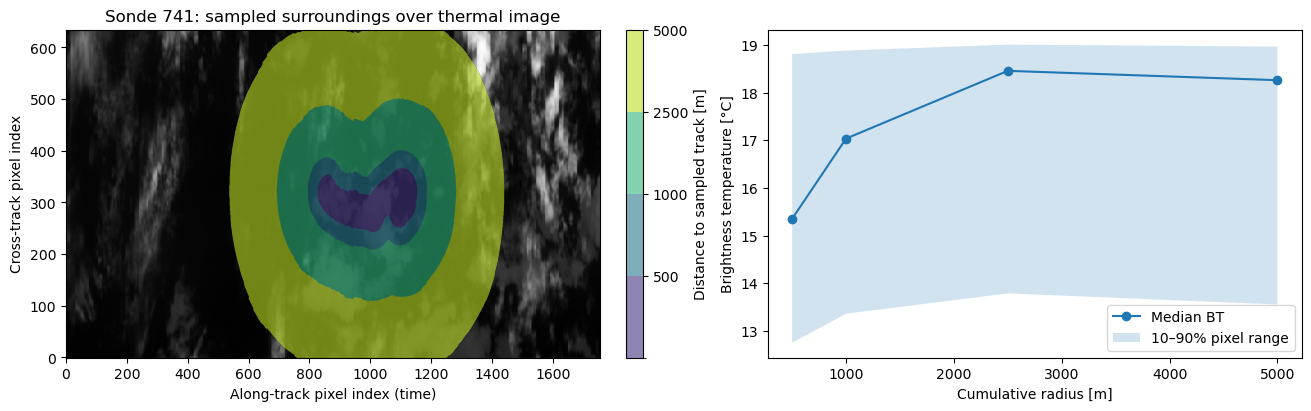

In [18]:
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap

if example_distance_m is not None:
    image = ds_velox_dropsonde[EXAMPLE_INDEX]
    sonde_i = ds_velox_dropsonde_indices[EXAMPLE_INDEX]
    sonde = ds_dropsonde.isel(sonde=sonde_i)
    bt = image.BT_2D
    if 'band' in bt.dims:
        bt = bt.isel(band=BAND_INDEX)
    # A pixel-grid map also works when some geolocation entries are missing.
    fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
    axes[0].imshow(bt.transpose('y', 'time'), origin='lower', aspect='auto', cmap='gray_r')
    zones = np.ma.masked_invalid(np.where(np.isfinite(example_distance_m), example_distance_m, np.nan))
    cmap = ListedColormap(plt.cm.viridis(np.linspace(0.15, 0.9, len(RADII_M))))
    artist = axes[0].imshow(zones, origin='lower', aspect='auto', alpha=0.6,
                            cmap=cmap, norm=BoundaryNorm(np.r_[0, RADII_M], cmap.N))
    fig.colorbar(artist, ax=axes[0], ticks=RADII_M, label='Distance to sampled track [m]')
    axes[0].set(xlabel='Along-track pixel index (time)', ylabel='Cross-track pixel index',
                title=f'Sonde {sonde_i}: sampled surroundings over thermal image')
    stats = track_bt_stats.query('velox_list_index == @EXAMPLE_INDEX')
    axes[1].plot(stats.radius_m, stats.bt_median, 'o-', label='Median BT')
    axes[1].fill_between(stats.radius_m.to_numpy(), stats.bt_p10.to_numpy(), stats.bt_p90.to_numpy(),
                         alpha=0.2, label='10–90% pixel range')
    axes[1].set(xlabel='Cumulative radius [m]', ylabel='Brightness temperature [°C]')
    axes[1].legend()
    plt.show()

### Compare thermal context with an inversion-height candidate

A [temperature inversion](https://glossary.ametsoc.org/wiki/temperature-inversion/) has
increasing air temperature with height. Here the candidate is the **midpoint of the
100 m layer with the largest temperature increase** between 500 and 4,000 m, requiring
at least 0.5 K warming. This configurable screening threshold is not a validated retrieval.
Only complete layers with `ta_qc == 0` qualify; missing layers are not interpolated.
No qualifying layer gives NaN. Inspect temperature profiles before treating this candidate
as the boundary-layer capping inversion; multiple or elevated inversions can occur.

The scatter plots show one point per sonde per radius, using cold-tail BT (10th percentile)
and BT spatial standard deviation. Neither is an updraft measurement or a cloud mask.
No minimum pixel-count cutoff is imposed; inspect `n_pixels` before interpreting small samples.
For vertical motion, [BEACH Level 4](https://orcestra-campaign.org/iwv_comparison.html)
provides circle-scale divergence/vertical velocity, not individual cloud rise speed.
The Level 3 descending sonde speed must not be interpreted as air vertical velocity.

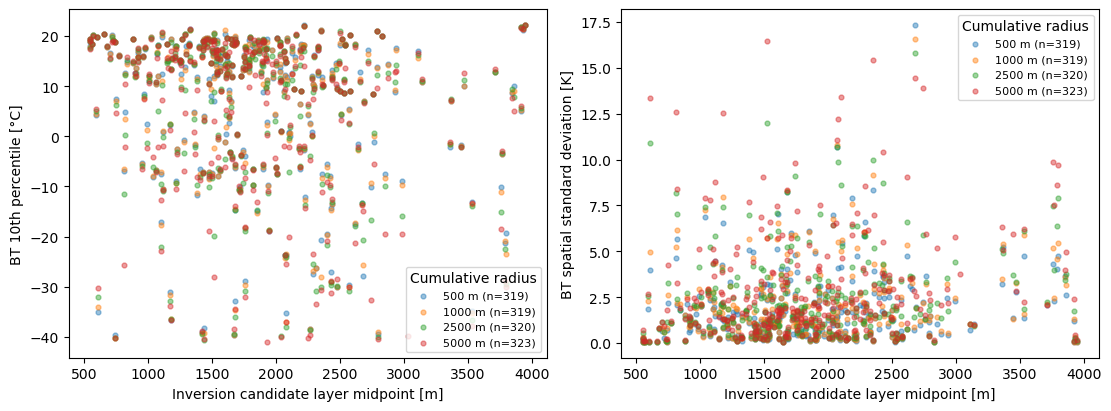

,velox_list_index,sonde_index,radius_m,n_geo_pixels,n_pixels,max_track_step_m,bt_mean,bt_std,bt_p10,bt_median,bt_p90,inversion_candidate_m,max_layer_warming_K
0,0,3,500.0,32790,32790,32.909916,15.217463,0.920617,14.203352,15.219363,16.222672,NaN,0.331665
1,0,3,1000.0,67268,67268,32.909916,14.314932,2.023032,11.918025,14.876802,15.985483,NaN,0.331665
2,0,3,2500.0,194620,194620,32.909916,10.704625,7.386861,-4.053796,14.407108,16.035423,NaN,0.331665
3,0,3,5000.0,471887,471887,32.909916,10.134533,7.563772,-4.129303,13.561458,16.409473,NaN,0.331665
4,1,4,500.0,28889,28889,175.477921,19.172289,0.887669,17.897911,19.284552,20.223000,1760.0,1.559784


In [19]:
INVERSION_RANGE_M = (500, 4000)
INVERSION_LAYER_M = 100
MIN_INVERSION_WARMING_K = 0.5

z = ds_dropsonde.altitude
assert z.attrs.get('units') == 'm', 'Expected altitude in metres'
assert ds_dropsonde.ta.attrs.get('units') == 'K', 'Expected BEACH temperature in kelvin'
assert np.allclose(np.diff(z.values), 10), 'This compact diagnostic expects the BEACH 10 m grid'
levels = int(round(INVERSION_LAYER_M / 10))
assert levels > 0 and np.isclose(levels * 10, INVERSION_LAYER_M)
temperature = ds_dropsonde.ta.where(ds_dropsonde.ta_qc == 0)
complete = temperature.notnull().rolling(altitude=levels + 1).sum().shift(altitude=-levels) == levels + 1
delta_t = (temperature.shift(altitude=-levels) - temperature).where(
    complete & (z >= INVERSION_RANGE_M[0]) & (z + INVERSION_LAYER_M <= INVERSION_RANGE_M[1])
)
strength = delta_t.max('altitude')
base_index = delta_t.fillna(-np.inf).argmax('altitude')
height = (z.isel(altitude=base_index) + INVERSION_LAYER_M / 2).where(strength >= MIN_INVERSION_WARMING_K)
inversion = pd.DataFrame({
    'sonde_index': np.arange(ds_dropsonde.sizes['sonde']),
    'inversion_candidate_m': height.values,
    'max_layer_warming_K': strength.values,
})
track_bt_stats = track_bt_stats.drop(columns=['inversion_candidate_m', 'max_layer_warming_K'], errors='ignore').merge(
    inversion, on='sonde_index', how='left', validate='many_to_one'
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for radius, group in track_bt_stats.groupby('radius_m'):
    for ax, metric in zip(axes, ['bt_p10', 'bt_std']):
        valid = group.dropna(subset=['inversion_candidate_m', metric])
        ax.scatter(valid.inversion_candidate_m, valid[metric], s=12, alpha=0.45, label=f'{radius:g} m (n={len(valid)})')
for ax, label in zip(axes, ['BT 10th percentile [°C]', 'BT spatial standard deviation [K]']):
    ax.set(xlabel='Inversion candidate layer midpoint [m]', ylabel=label)
    ax.legend(title='Cumulative radius', fontsize=8)
plt.show()
track_bt_stats.head()